<a href="https://colab.research.google.com/github/rpark3/ECON3916-Statistical-Machine-Learning/blob/main/Final%20Project%20/%203916_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [4]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can health, demographic, and behavioral indicators predict whether an individual has diabetes?

**This is a prediction (umbrella) problem because:**
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

This is a prediction problem because the goal is to observe different variables to predict whether someone may have diabetes from X, rather then estimate whether X causes diabetes.

**The decision this enables:**
(Who is the stakeholder? What action would they take differently with your prediction?)

A public health screening program or clinic could use the model to identify people at higher predicted risk of diabetes and prioritize them for follow up appointments or early intervention.

**Dataset:** Diabetes Health Indicators Dataset
- **Source:**  (URL: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data)
- **N =** 253,680 obersvations
- **Features =** 21 variables
- **Target variable =** Diabetes_binary
- **Access date:** April 18th, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-health-indicators-dataset


In [6]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv('/kaggle/input/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

# Uncomment and modify one of the lines above
# df = pd.read_csv('___')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (253680, 22)
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### 2.2 Basic Description

In [7]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


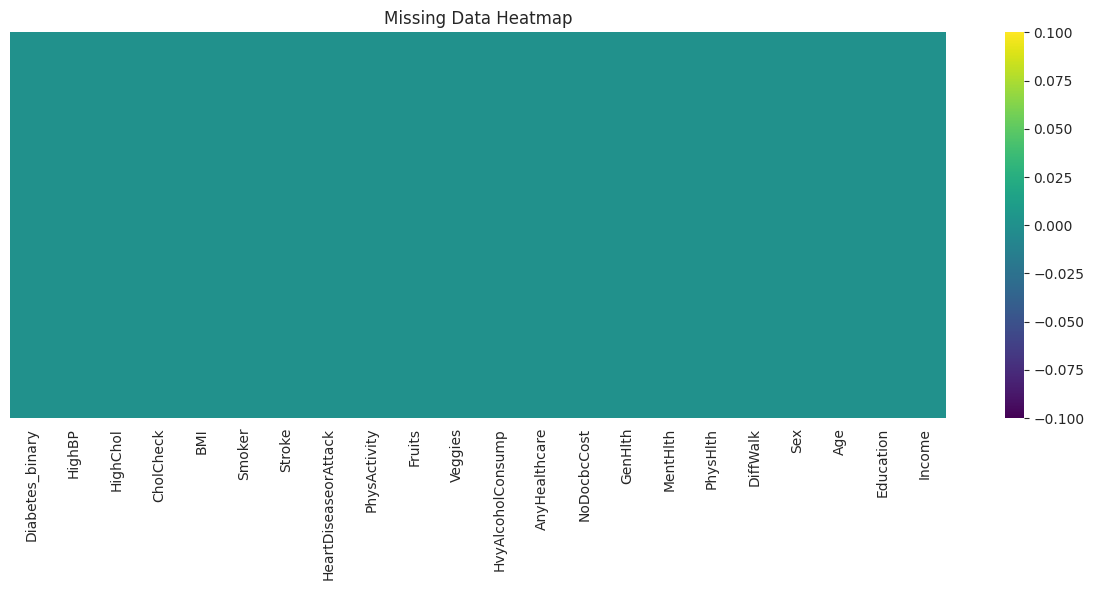

In [8]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# # Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:**
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)
The CDC dataset has no missing values

### 2.4 Distribution Plots

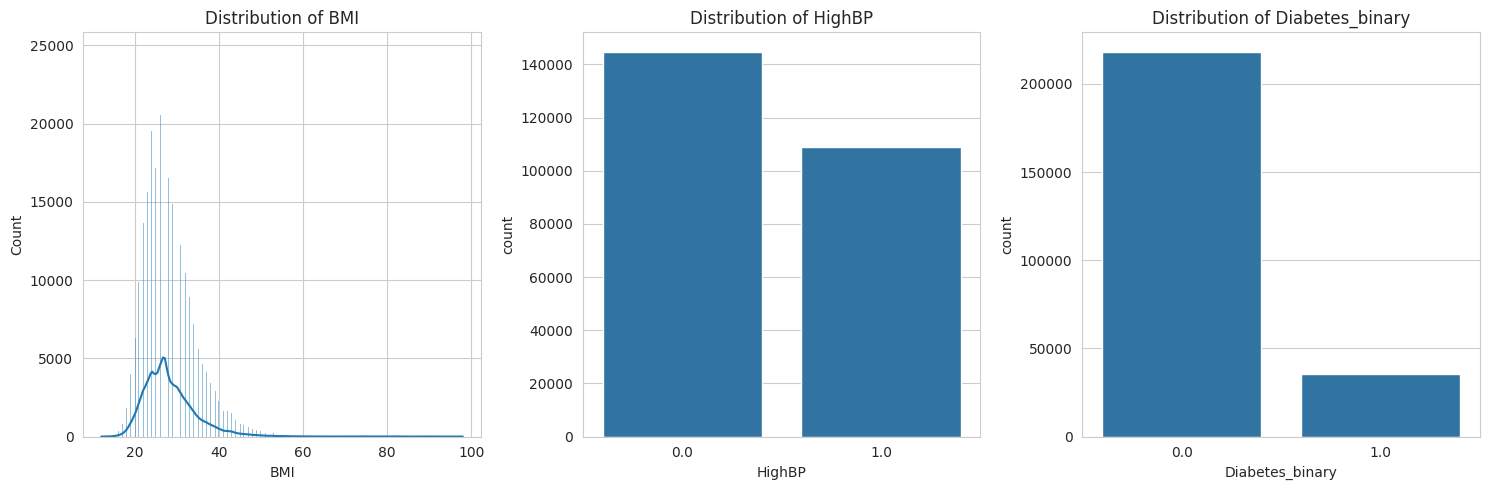

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# # Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['BMI'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of BMI')

sns.countplot(x=df['HighBP'], ax=axes[1])
axes[1].set_title('Distribution of HighBP')

sns.countplot(x=df['Diabetes_binary'], ax=axes[2])
axes[2].set_title('Distribution of Diabetes_binary')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [10]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
     """Return lower and upper Tukey fences."""
     Q1 = series.quantile(0.25)
     Q3 = series.quantile(0.75)
     IQR = Q3 - Q1
     return Q1 - k * IQR, Q3 + k * IQR
#
# # Example: check outliers in a numeric column
col = 'BMI'
lower, upper = tukey_fences(df[col])
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

BMI: 9847 outliers (3.9%)


**Outlier strategy:**
(Trim? Winsorize? Keep with justification?)
In this dataset potential outliers will be kept, as extreme values may indicate health risks.

### 2.6 Correlations

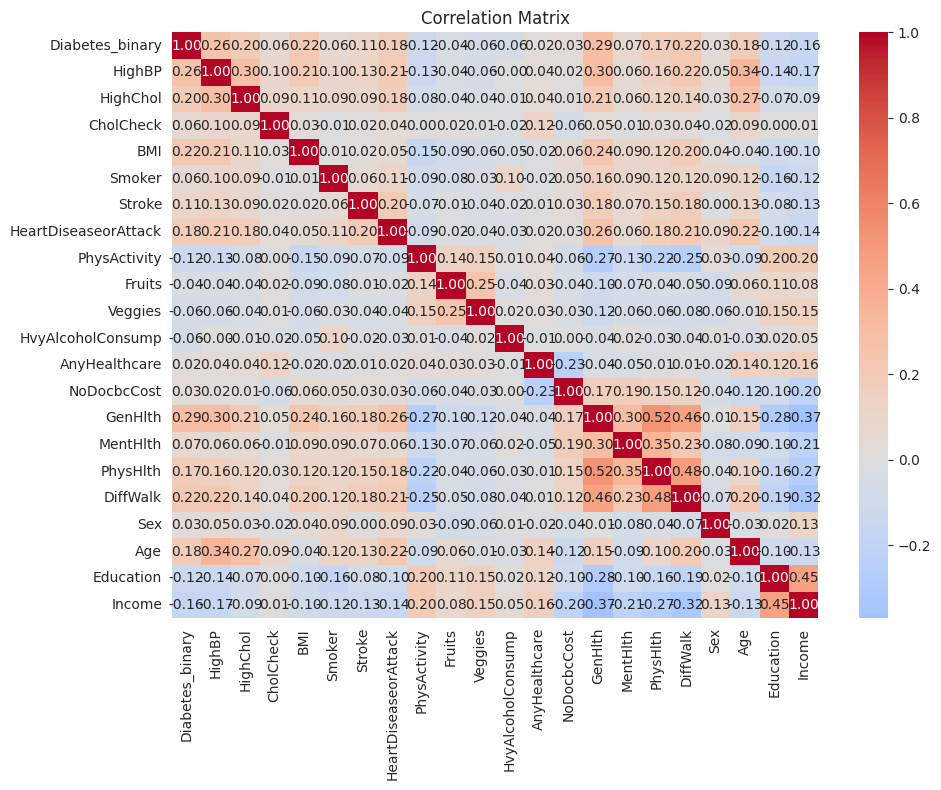

In [11]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
#
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable, Diabetes_binary, is not balanced with many more non diabetes observations than diabetes observations. Due to this, looking at accuracy alone can be misleading. I will handle this by using proper metrics such as F1-score, ROC-AUC, and precision recall curves.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* The features that appear to be most correlated with the targer are GenHlth, HighBP, BMI, HighChol, and PhysHlth. Some features that are highly correlated with eachother are Genhlth and PhysHlth, PhysHlth and and diffwalk, and education and income.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue is class imbalance. The dataset doesn't have any missing values, so the main issue is that the imbalance may bias evaluation.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 253,680 ** observations and **M = 21** features.

**Missing data:** 0% of cells are missing.

**Outliers:** I identified potential outliers using Tukey Fences and IQR. I will handle them by keeping them in, as these values may reflect health conditions.

**Target variable:** [Describe distribution — class balance or spread].

Diabetes_binary - binary classification and the distrbution is imbalanced, with many more non diabetes than diabetes.

**Key finding from EDA:** the variables most correlated with diabetes appear to be general health, high blood pressure, BMI, difficulty walking, higher cholesterol, and age.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [12]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# # Define features and target
X = df.drop(columns=['Diabetes_binary'])  # Replace with your features
y = df['Diabetes_binary']  # Replace with your target
#
# # For classification: use stratify=y
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
 )

#
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 202944 samples
Test:  50736 samples


### 3.2 Model 1: Baseline

In [13]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
# Choose a simple, interpretable baseline:
#   Classification: LogisticRegression
#   Regression: LinearRegression or Ridge

from sklearn.linear_model import LogisticRegression  # or LinearRegression, Ridge
#
model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model_1.fit(X_train, y_train)
#
y_pred_1 = model_1.predict(X_test)
#
# # Classification metrics
print('Model 1: Logistic Regression')
print(classification_report(y_test, y_pred_1))
#
# # Regression metrics (use these instead if regression)
# # print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
# # print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
# # print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Logistic Regression
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



### 3.3 Model 2: Your Choice

In [14]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
# Choose a more flexible model:
#   Classification: RandomForestClassifier, GradientBoostingClassifier
#   Regression: RandomForestRegressor, GradientBoostingRegressor

from sklearn.ensemble import RandomForestClassifier  # or RandomForestRegressor
#
model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)
#
y_pred_2 = model_2.predict(X_test)
#
print('Model 2: Random Forest')
print(classification_report(y_test, y_pred_2))

Model 2: Random Forest
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



### 3.4 Cross-Validation Comparison

In [15]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
scoring = 'roc_auc'
#
cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
comparison = pd.DataFrame({
     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
 })
# comparison

Model 1 CV roc_auc: 0.8227 +/- 0.0026
Model 2 CV roc_auc: 0.8015 +/- 0.0017


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

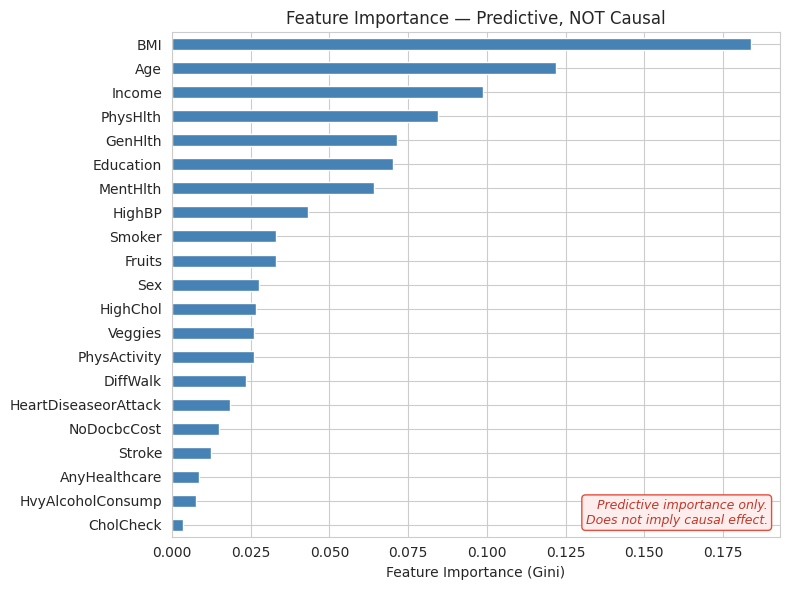

In [20]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
importances = pd.Series(
     model_2.feature_importances_, index=X.columns
 ).sort_values(ascending=True)
#
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
ax.text(
     0.98, 0.02,
     'Predictive importance only.\nDoes not imply causal effect.',
     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
     style='italic', color='#c0392b',
     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)
#
plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

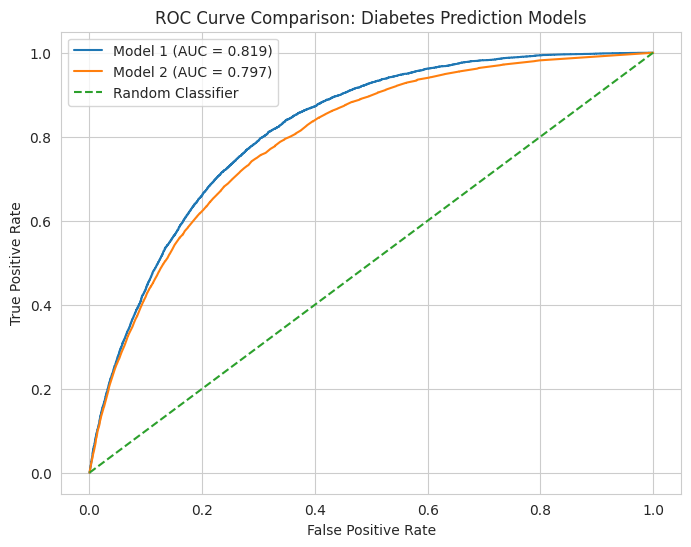

In [22]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

from sklearn.metrics import roc_curve, roc_auc_score
# Predicted probabilities
y_prob_1 = model_1.predict_proba(X_test)[:, 1]
y_prob_2 = model_2.predict_proba(X_test)[:, 1]

# ROC data
fpr1, tpr1, _ = roc_curve(y_test, y_prob_1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_2)

auc1 = roc_auc_score(y_test, y_prob_1)
auc2 = roc_auc_score(y_test, y_prob_2)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'Model 1 (AUC = {auc1:.3f})')
plt.plot(fpr2, tpr2, label=f'Model 2 (AUC = {auc2:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Diabetes Prediction Models')
plt.legend()
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___